# Practical examples of prediction algorithms for different types of noise

This notebook provides a guided and applied introduction to a range of widely used noise prediction algorithms, illustrated through practical examples drawn from real engineering applications. We focus on four representative and technologically relevant cases: jet noise, propeller noise, cavity noise, and wind turbine noise. Each of these sources is governed by different physical mechanisms and modelling assumptions, making them ideal case studies for understanding both the strengths and limitations of modern aeroacoustic prediction methods. The selected examples reflect current challenges in noise reduction for aerospace and energy systems, where accurate noise prediction plays a key role in design optimisation, regulatory compliance, and public acceptance.

By working through these cases, you will gain insight into how  different flow regimes and geometries influence the predicted spectra and directivity.

> **Please note**: All examples shown here take algorithms and equations found in literature. These will be linked when used throughout the exercise. 


## Wind Turbine Noise
<center>
    <img src="windturbine.png" width="700">
    <br>
    Photo of a windturbine blade in front of a full moon by Peter Dargatz from pixabay
</center>

###
The first case we will explore is that of wind turbine noise as studied in Module 2.1. As we have learnt; different mechanisms may contribute to this aerodynamic noise, but the most important is usually trailing edge noise, which is caused by the turbulent air flow over the blades. We can see that trailing edge noise scales with the 5th power of the flow speed, the length of the blade section, and the square of the distance to the observer. Due to the different sizes and velocities of the turbulence in the boundary layer, trailing edge noise has a broadband character, meaning it contains many frequencies.

**Amiet’s** approach assumes that the turbulent flow approaching the trailing edge can be modelled via its integral fluctuating pressure on the surface. Think of it as counting the number of people passing through a gate by tracking their footprints. The idea is similar: turbulent velocity fluctuations produce pressure fluctuations that, when scattered at the edge, radiate as dipolar sound. To simplify, Amiet assumed:

1. The turbulent fluctuations are small compared to the mean flow velocity.
2. The interaction between the airfoil and the turbulence is locally inviscid near the trailing edge.
3. The turbulent properties remain unchanged as they are convected by the mean flow.

### Surface Pressure Fluctuations
The trailing-edge noise-computation for a wind turbine starts from the estimation of the surface pressure-fluctuations at the blade trailing edge. The latter can be used as input in Amiet's trailing-edge noise-model for example. As a first approximation we can consider the blade constituted by several airfoils (i.e. blade sections), each one rotating at a specific speed, and therefore with a specific incoming velocity. In this example here below, we focus on a single airfoil, and we determine the spectral distribution of the surface pressure-fluctuations, in function of their frequency content. The equations to find the surface pressure fluctuations is presented below. The derivation of this equation can be found in the paper by Michael Goody. It is referenced at the bottom of this notebook.

<center>
    <img src="wallPressure.png">
</center>


Look through the code below to understand each variable and run it to obtain a plot with sliders. Through these sliders you will be able to see the effects of different variables on the spectral density as a function of frequency. When you have found a configuration, of the sliders, that satisfy you, download the CSV file of the wall pressure spectra and then use it as an input in Amiet's model. 


In [10]:
from IPython.display import IFrame

IFrame(
    src="https://ajohary.github.io/AeroacousticsNoiseReductionStrategiesPracticalExamples/windTurbineWallPP.html",
    width="1000",
    height="1000"
)

Some **questions** that are important for you to think about as you interact with the plot above:  
1. How does the spectrum change with changes in flow velocity?
2. How does the spectrum change with an increasing pressure gradient coefficient? Do you know the attributes that affect the pressure gradient?
3. What does the chordwise distance from the trailing edge (TE) tell you about where the most noise is being produced?


### Predicted noise in far field
Now, as understood, use the file you downloaded as an input in the code below to see the SPL spectrum of a wind turbine in the far field according to the conditions you decided using the sliders.

The power spectrum density of what it is heard at a specific receiver position, discussed in the lectures, is given by the expression below.
<center>
    <img src="farFieldNoise.png" width="700">
</center>

**Now, you will be doing some of the setting up for the next node to work!**

To run this step, you need to download the csv file from the plot above. This saves the normalized wall pressure spectrum that you generated based on the sliders. Once you have it downloaded, you need to uploaded it here! Direct yourself to the folder icon on the left menu to upload a file and upload that csv file.

In the code block below, you will manipulate STEP 2 and STEP 6. **In STEP 2**, you will need to add the title of the file you have uploaded. A default title is already in place but depending on your title, this might change! **In STEP 6**, you will change the parameters to ones that either are consistent with the wall pressure spectrum parameters (velocity, chordwise distance to TE (x/c)) or you will manipulate parameters (like distance and angle of attack) to explore the sound power level equation. 



Far-Field Pressure Spectrum Calculator
✓ Data loaded successfully!
  Number of rows: 1000

✓ Frequency range: [1.0000e-03, 1.0000e+04] Hz
✓ Omega range: [6.2832e-03, 6.2832e+04] rad/s
✓ Phi_pp range: [7.4127e-12, 6.8623e-01]

CALCULATING FAR-FIELD PRESSURE SPECTRUM

Input Parameters:
  Wind velocity (U):        30.0 m/s
  Mach number (M):          0.0875
  Observation angle (θ):    90.0°
  Observer distance (S₀):   10.0 m
  Blade span (L):           1.0 m
  Chord length (c):         1.0 m
  Chordwise position (x/c): 1.0
  Angle of attack (α):      0.0°

✓ Chordwise distance x3:  1.00 m
✓ Pressure spectrum S_pp range: [8.5728e-25, 6.7812e-11] Pa²/Hz
✓ Sound Pressure Level (narrow-band) range: [-130.9, -18.5] dB
✓ Sound Pressure Level (1/3-octave) range: [-114.3, -6.7] dB
✓ Number of 1/3-octave bands: 41
✓ Sound Power Level (PWL) range: [-105.6, 70.3] dB


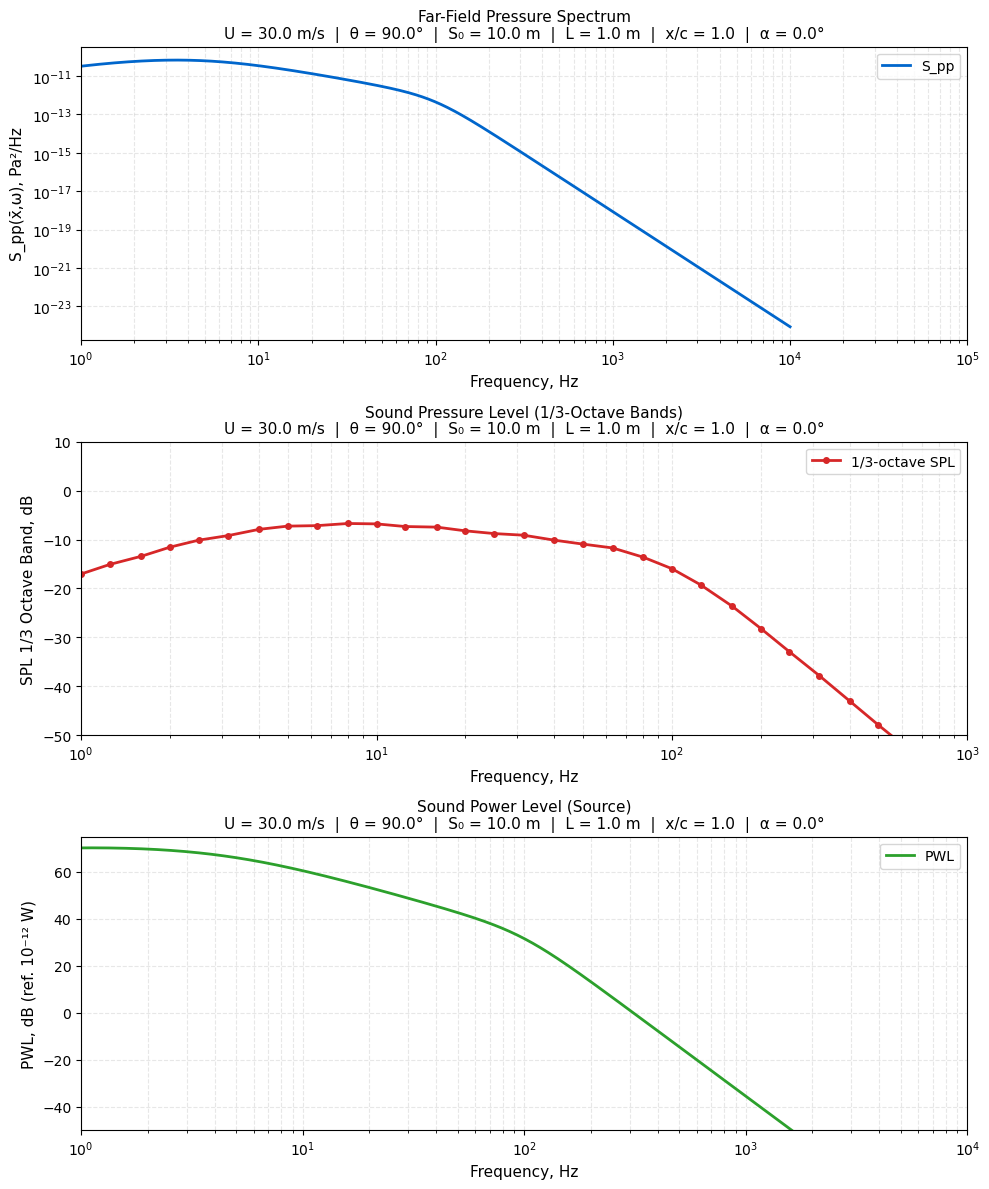


✓ Three plots created!

Plot 1 - Far-field Pressure Spectrum (S_pp):
  Raw pressure spectrum at observer location
  Units: Pa²/Hz (mean-square pressure per unit frequency)

Plot 2 - Sound Pressure Level (1/3-Octave Bands):
  Acoustic pressure level in standard 1/3-octave bands
  Standard bands per ANSI S1.11
  Units: dB re 20 μPa
  Each bar represents integrated SPL over one 1/3-octave band

Plot 3 - Sound Power Level (PWL):
  Total acoustic power radiated by source (independent of S₀)
  Units: dB re 10⁻¹² W

To explore different scenarios:
  1. Change the values in STEP 7 (marked clearly above)
  2. Re-run this cell
  3. All plot titles will automatically update!


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# --------- STEP 1: FUNCTION FOR DATA READING -----------


def read_wall_pressure_spectrum(filename):

    # Read file
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)
    elif filename.endswith('.xlsx'):
        df = pd.read_excel(filename)
    else:
        raise ValueError("File must be .csv or .xlsx")

    # Extract first two columns
    freq = df.iloc[:, 0].to_numpy(dtype=float)
    S_pp = df.iloc[:, 1].to_numpy(dtype=float)

    # Safety checks
    if np.any(freq <= 0):
        raise ValueError("Frequency must be strictly positive.")

    if np.any(S_pp < 0):
        raise ValueError("S_pp must be non-negative.")

    return freq, S_pp
    
# === STUDENT INPUT: INPUT YOUR FILE NAME HERE =========
filename = "Phi_pp_spectrum.csv"  

freq, S_pp = read_wall_pressure_spectrum(filename)

 
# ---------------- STEP 2: PROCESS DATA ----------------------------

print("="*60)
print("Far-Field Pressure Spectrum Calculator")
print("="*60)

# Convert frequency to angular frequency
omega = freq * 2 * np.pi
phi_pp = S_pp

# Rename for consistency with rest of code
nu = freq

print(f"✓ Data loaded successfully!")
print(f"  Number of rows: {len(freq)}\n")
print(f"✓ Frequency range: [{freq.min():.4e}, {freq.max():.4e}] Hz")
print(f"✓ Omega range: [{omega.min():.4e}, {omega.max():.4e}] rad/s")
print(f"✓ Phi_pp range: [{phi_pp.min():.4e}, {phi_pp.max():.4e}]")

# --------- STEP 3: DEFINING ACOUSTIC PARAMETERS-----------

c = 1.0           # Chord length, m
x3 = c            # Chordwise position at trailing edge, m
c0 = 343.0        # Sound velocity, m/s
rho0 = 1.225      # Air density, kg/m³


# --------- STEP 4: AIRFOIL RESPONSE FUNCTION -----------

def airfoil_response_L2(omega, Ky, U):
    """
    Simplified airfoil response function for trailing edge noise.
    """
    k = omega / U  # Convective wave number
    return 1.0 / (1.0 + (k * c)**2)


# --------- STEP 5: SPANWISE CORRECTION -----------

def spanwise_correction(omega, U):
    return np.where(omega > 0, 0.1 * U / omega, 0.1 * U / 0.01)

    

# --------- STEP 6: FAR FIELD SPECTRA FUNCTIONS  -----------

def calculate_sound_pressure_spectrum(omega, phi_pp, U, x3, c, c0, S0, L, Ky=1.0):
    """
    Calculate far-field pressure spectrum S_pp(x, omega) at observer location.
    
    Based on: S_pp = (ωcx₃/(4πc₀S₀²))² × (L/2) × Φ_pp(ω) × ℓ_y(ω) × L²(ω/U, K_y)
    
    This represents the mean-square pressure fluctuations per unit frequency
    at the observer position.
    """
    # Geometric factor: (ωcx₃/(4πc₀S₀²))²
    geometric_factor = (omega * c * x3 / (4 * np.pi * c0 * S0**2))**2
    
    # Spanwise correlation length
    ly = spanwise_correction(omega, U)
    
    # Airfoil response function L²(ω/U, K_y)
    L2_response = airfoil_response_L2(omega, Ky, U)

    # Complete formula from the image
    S_pp = geometric_factor * (L / 2) * phi_pp * ly * L2_response
    
    return S_pp

def calculate_SPL(S_pp, freq):

    p_ref = 20e-6  # Reference pressure, Pa (20 μPa)

    df = np.gradient(freq)  
    p_squared = S_pp * df   
    
    p_squared_safe = np.maximum(p_squared, p_ref**2 * 1e-10)
    SPL = 10 * np.log10(p_squared_safe / p_ref**2)
    
    return SPL

def calculate_narrowband_SPL(S_pp, freq):
    """
    Calculate narrowband Sound Pressure Level.
    
    S_pp is a power spectral density (Pa²/Hz)
    To get mean-square pressure in each band: p² = S_pp × Δf
    SPL = 10 log₁₀(p²/p_ref²)
    """
    p_ref = 20e-6  # Pa (reference pressure for air)

    # Calculate frequency bin widths
    df = np.diff(freq, prepend=freq[0])

    # Mean-square pressure in each frequency bin
    p2 = S_pp * df

    # Avoid log of zero or negative
    p2[p2 <= 0] = np.finfo(float).eps

    # Sound Pressure Level
    SPL = 10 * np.log10(p2 / p_ref**2)

    return SPL

def calculate_one_third_octave_SPL(S_pp, freq):
    """
    Calculate 1/3-octave band Sound Pressure Level.
    
    For each 1/3-octave band:
    1. Integrate S_pp over the frequency range [f_lower, f_upper]
    2. p²_band = ∫ S_pp(f) df
    3. SPL = 10 log₁₀(p²_band / p_ref²)
    """
    p_ref = 20e-6  # Pa

    # Standard 1/3-octave center frequencies (ANSI S1.11)
    f_center = np.array([
        1.0, 1.25, 1.6, 2.0, 2.5, 3.15, 4.0, 5.0, 6.3, 8.0,
        10, 12.5, 16, 20, 25, 31.5, 40, 50, 63, 80,
        100, 125, 160, 200, 250, 315, 400, 500, 630, 800,
        1000, 1250, 1600, 2000, 2500, 3150, 4000, 5000, 6300, 8000,
        10000, 12500, 16000, 20000, 25000, 31500, 40000, 50000, 63000, 80000,
        100000
    ])
    
    # Only use bands within the data frequency range
    f_center = f_center[(f_center >= freq.min()) & (f_center <= freq.max())]
    
    # 1/3-octave bandwidth factor: 2^(1/6) ≈ 1.1225
    factor = 2**(1/6)
    f_lower = f_center / factor
    f_upper = f_center * factor
    
    SPL_third_octave = np.zeros(len(f_center))
    
    for i, (fl, fu) in enumerate(zip(f_lower, f_upper)):
        # Find frequencies within this band
        mask = (freq >= fl) & (freq < fu)
        
        if np.any(mask):
            # Integrate S_pp over the band using trapezoidal rule
            df = np.gradient(freq[mask])
            
            # Total mean-square pressure in the band
            p2_band = np.sum(S_pp[mask] * df)
            
            # SPL for this 1/3-octave band
            SPL_third_octave[i] = 10 * np.log10(np.maximum(p2_band, 1e-30) / p_ref**2)
        else:
            SPL_third_octave[i] = -np.inf
    
    # Remove invalid bands
    valid = np.isfinite(SPL_third_octave)
    f_center = f_center[valid]
    SPL_third_octave = SPL_third_octave[valid]
    
    return f_center, SPL_third_octave

def calculate_sound_power(omega, phi_pp, U, x3, c, c0, L, Ky=1.0):

    M = U / c0
    
    ly = spanwise_correction(omega, U)
    
    L2_response = airfoil_response_L2(omega, Ky, U)
    
    # Acoustic power spectrum (simplified model)
    # Based on Amiet/Brooks trailing edge noise theory
    # W(ω) ∝ M⁵ × L × c × Φ_pp × l_y × L²(ω/U, Ky)
    
    W_omega = (
        (rho0 * c0 * M**5) *  # Mach number scaling
        L * c *                # Geometric factors
        phi_pp *               # Wall-pressure spectrum
        ly *                   # Span-wise correlation
        L2_response            # Acoustic efficiency
    )
    
    return W_omega

def calculate_PWL(W_omega, freq):
    """
    Calculate Sound Power Level from acoustic power spectral density.
    
    W_omega is a power spectral density (W/Hz)
    To get power in each frequency band: W = W_omega × Δf
    PWL = 10 log₁₀(W / W_ref) where W_ref = 10⁻¹² W
    """
    W_ref = 1e-12  # Reference acoustic power, W
    
    # Calculate frequency bin widths
    df = np.gradient(freq)
    
    # Power in each frequency band
    W_total = W_omega * df
    
    # Sound Power Level in dB
    PWL = 10 * np.log10(np.maximum(W_total, 1e-30) / W_ref)
    
    return PWL

# ==========================================================
# STEP 7: STUDENT PARAMETERS 
# ==========================================================
# 
# STUDENTS: Modify the values below to explore different scenarios
# The plot will automatically update with your new values
#
# ==========================================================

# Flow Conditions
U = 30.0                    # Wind velocity [m/s] - typical range: 10-80 m/s

# Observer Position
theta = 90.0                # Observation angle [degrees] - range: 0-180°
                            # 0° = upstream, 90° = perpendicular, 180° = downstream
S0 = 10.0                   # Observer distance [m] - typical range: 1-100 m

# Geometry
L = 1.0                     # Blade span [m] - typical range: 0.5-10 m
x_over_c = 1.0              # Chordwise position x/c - range: 0.2-1.0
                            # 1.0 = trailing edge (TE), <1.0 = upstream of TE
alpha = 0.0                 # Angle of attack [degrees] - typical range: -10 to +20°

# --------- STEP 8: CHECKS AND CALCULATIONS -----------


print("\n" + "="*60)
print("CALCULATING FAR-FIELD PRESSURE SPECTRUM")
print("="*60)
print("\nInput Parameters:")
print(f"  Wind velocity (U):        {U} m/s")
print(f"  Mach number (M):          {U/c0:.4f}")
print(f"  Observation angle (θ):    {theta}°")
print(f"  Observer distance (S₀):   {S0} m")
print(f"  Blade span (L):           {L} m")
print(f"  Chord length (c):         {c} m")
print(f"  Chordwise position (x/c): {x_over_c}")
print(f"  Angle of attack (α):      {alpha}°")

x3 = x_over_c * c  
Ky = 2 * np.pi * np.sin(np.radians(theta)) / c  
S_pp = calculate_sound_pressure_spectrum(omega, phi_pp, U, x3, c, c0, S0, L, Ky)

SPL_narrowband = calculate_narrowband_SPL(S_pp, nu)
f_third_octave, SPL_third_octave = calculate_one_third_octave_SPL(S_pp, nu)

W_omega = calculate_sound_power(omega, phi_pp, U, x3, c, c0, L, Ky)
PWL = calculate_PWL(W_omega, nu)

print(f"\n✓ Chordwise distance x3:  {x3:.2f} m")
print(f"✓ Pressure spectrum S_pp range: [{S_pp.min():.4e}, {S_pp.max():.4e}] Pa²/Hz")
print(f"✓ Sound Pressure Level (narrow-band) range: [{SPL_narrowband.min():.1f}, {SPL_narrowband.max():.1f}] dB")
print(f"✓ Sound Pressure Level (1/3-octave) range: [{SPL_third_octave.min():.1f}, {SPL_third_octave.max():.1f}] dB")
print(f"✓ Number of 1/3-octave bands: {len(f_third_octave)}")
print(f"✓ Sound Power Level (PWL) range: [{PWL.min():.1f}, {PWL.max():.1f}] dB")

# --------- STEP 9: PLOTTING -----------

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

title_params = f'U = {U} m/s  |  θ = {theta}°  |  S₀ = {S0} m  |  L = {L} m  |  x/c = {x_over_c}  |  α = {alpha}°'

# Plot 1: Far-field Pressure Spectrum (S_pp)
ax1.loglog(nu, S_pp, lw=2, color='#0066cc', label='S_pp')
ax1.set_xlabel('Frequency, Hz', fontsize=11)
ax1.set_ylabel('S_pp(x̄,ω), Pa²/Hz', fontsize=11)
ax1.set_title(f'Far-Field Pressure Spectrum\n{title_params}', fontsize=11)
ax1.grid(True, which='both', ls='--', alpha=0.3)
ax1.set_xlim([1, 1e5])
ax1.legend(loc='best')

# Plot 2: Sound Pressure Level (1/3-octave bands)
ax2.semilogx(f_third_octave, SPL_third_octave, 'o-', lw=2, markersize=4,
             color='#d62728', label='1/3-octave SPL')
ax2.set_xlabel('Frequency, Hz', fontsize=11)
ax2.set_ylabel('SPL 1/3 Octave Band, dB', fontsize=11)
ax2.set_title(f'Sound Pressure Level (1/3-Octave Bands)\n{title_params}', fontsize=11)
ax2.grid(True, which='both', ls='--', alpha=0.3)
ax2.set_xlim([1, 1e3])
ax2.set_ylim([-50, 10])
ax2.legend(loc='best')

# Plot 3: Sound Power Level (PWL)
ax3.semilogx(nu, PWL, lw=2, color='#2ca02c', label='PWL')
ax3.set_xlabel('Frequency, Hz', fontsize=11)
ax3.set_ylabel('PWL, dB (ref. 10⁻¹² W)', fontsize=11)
ax3.set_title(f'Sound Power Level (Source)\n{title_params}', fontsize=11)
ax3.grid(True, which='both', ls='--', alpha=0.3)
ax3.set_xlim([1, 1e4])
ax3.set_ylim([-50, 75])
ax3.legend(loc='best')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✓ Three plots created!")
print("="*60)
print("\nPlot 1 - Far-field Pressure Spectrum (S_pp):")
print("  Raw pressure spectrum at observer location")
print("  Units: Pa²/Hz (mean-square pressure per unit frequency)")
print("\nPlot 2 - Sound Pressure Level (1/3-Octave Bands):")
print("  Acoustic pressure level in standard 1/3-octave bands")
print("  Standard bands per ANSI S1.11")
print("  Units: dB re 20 μPa")
print("  Each bar represents integrated SPL over one 1/3-octave band")
print("\nPlot 3 - Sound Power Level (PWL):")
print("  Total acoustic power radiated by source (independent of S₀)")
print("  Units: dB re 10⁻¹² W")
print("\nTo explore different scenarios:")
print("  1. Change the values in STEP 7 (marked clearly above)")
print("  2. Re-run this cell")
print("  3. All plot titles will automatically update!")


As you can see the three plots above show the direct SPP output, the sound power level emitted at the source and the sound pressure level dependent on the distance of the observer. Change the parameters in step 7 to understand the relation between each metric!  

## Aircraft Propeller Noise - Tonal Components

<center>
    <img src="propeller.png" width="300">
    <br>
    Photo of an aircraft propeller by <a href="https://unsplash.com/@sevcanalkan?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Sevcan Alkan</a> on <a href="https://unsplash.com/photos/airplane-propeller-against-a-clear-blue-sky-ncPXZcrvDyU?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
</center>

###
The most important noise contribution from a propeller is the **tonal one** derived from the thickness and loading distributions of the blade. As you have studied, the propeller blade rotation displaces the blade geometry in the flow. From the flow viewpoint at every instant of time, the perturbation of the blade moving is felt as a local flow ejection (i.e. the flow is displaced by the blade movement) and as a varying force in space (i.e. the blade loading). These two contributions determine tonal noise component since they are associated to the blade rotational frequency. Additional broadband components are determined by the blade wakes; however, they are generally less loud than the former source. The equation used to calculate the harmonics is as follows:

<center>
    <img src="propellerNoise.png">
</center>


This example assumes a Twin Otter, three-bladed propeller with D=0.21m is considered in static conditions, the observer is located in the propeller disk plane at a distance of 10D at an angle of 90° with respect to the propeller axis, and upstream of it 0°, respectively. The propeller rotatates at 230Hz.

In [3]:
from IPython.display import IFrame

IFrame(
    src="https://ajohary.github.io/AeroacousticsNoiseReductionStrategiesPracticalExamples/propNoiseBPF.html",
    width="1000",
    height="1250"
)

It is interesting to note how each parameter influences the magnitude and the frequencies of the harmonics. Here, logically, the broadband contributions are not considered. While carrying out this exercise, ask yourself the following: 
1. Which parameters influence the shift versus the magnitude of the tones?
2. How would changes in the diameter affect tonal noise?
3. What could be one way to reduce the tonal noise? Does a reduction also mean moving tones to a lower frequency? Why or why not?

## Jet Noise


<center>
    <img src="airplaneCity.png" width="300">
    <br>
    Photo of an airplane in between city buildings by <a href="https://unsplash.com/@velor?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Alexander Kotlyar</a> on <a href="https://unsplash.com/photos/white-airplane-on-mid-air-s0cF8DH8DBg?utm_source=unsplash&utm_medium=referral&utm_content=creditCopyText">Unsplash</a>
</center>

###
Many noise prediction algorithms start from Lighthill's acoustic analogy, with a series of approximations and modelling strategies to avoid integrating Lighthill's tensor in space and time in the jet volume. As you have seen already from the study of Tam and Aurialt, the integration starts from realizing that the spectrum in the far field is related to the two-point cross-correlation function of Lighthill's stress tensor in the jet field. This is mainly because many of the points in the jet-volume can be assumed as aeroacoustic sources, interfering with each other. For compact sources, after modelling the two-point cross-correlation function as a Gaussian distribution, the formula for the jet noise in the far field (simplified at an angle of 90 degrees from the jet axis is reported here:

<center>
    <img src="jetNoise.png" width = "700">
</center>

It is important to note that there is a turbulent model used here and the coefficient values of it are highly dependent on flow conditions and geometries of the object in the flow. For this example, emperical values for a jet noise have been considered to simplify the example at hand. Below you will see two plots, one is the power spectral density (PSD) which is the direct result of the equation above and the second one is the calculated SPL spectrum from the PSD. Once again, there are sliders below that allow you to explore the dependencies of different parameters and the metrics you see. 

In [6]:
from IPython.display import IFrame

IFrame(
    src="https://ajohary.github.io/AeroacousticsNoiseReductionStrategiesPracticalExamples/jetNoise.html",
    width="1000",
    height="1650"
)

At this point we have seen so many situations that have different relations and prediction models, keeping the following questions in mind is important: 
1. Why are so many different metrics used?
2. What do all the different equations/relations insinuate when considering different examples? What does this say about the noise source types? 

## Nomenclature

Below is a list of the nomenclature seen from the equations mentioned throughout the notebook.

### Greek Symbols

| Symbol | Description | Units/Value |
|--------|-------------|-------------|
| ω̄ | Strouhal number | ωδ*/U |
| βc | Clauser's parameter | θ/τω · dp/dx |
| Δ | Zagarola and Smit parameter | δ/δ* |
| δ(x) | Boundary layer thickness | m |
| δ*(x) | Boundary layer displacement thickness | m |
| L₂ | Airfoil response function | - |
| μ | Dynamic viscosity | kg·m⁻¹·s⁻¹ |
| ν | Frequency | Hz |
| ω | Angular frequency | 2πν, rad·s⁻¹ |
| ω₀ | Characteristic frequency | 2π/τs |
| Π | Wake strength parameter | 0.8(βc + 0.5)⁰·⁷⁵ |
| ψL | Noncompactness factor for rectangular loading | sin(X)/X |
| ρ | Air density | 1.225 kg/m³ |
| ρ₀ | Mean density in the source region | - |
| τ₀ | - | cτ/k·ε |
| τω(x) | Shear stress | μ·dU/dy, Pa |
| τmax | Maximum shear stress | - |
| θ | Retarded radiation angle | cos θ = cos θ₁/√(1 - M²ₓ sin² θ₁) + Mₓ sin² θ₁ |
| θ(x) | Momentum thickness | m |

### Latin Symbols

| Symbol | Description | Units/Value |
|--------|-------------|-------------|
| A | Magnitude of the correlation | - |
| A₁ | - | 3.7 + 1.5βc |
| A₂ | - | min(√(3.19/RT)) |
| B | Number of rotor blades | - |
| c | Chord length | m |
| c₀ | Sound velocity | m·s⁻¹ |
| c∞ | Sound velocity in air | 343 m/s |
| D | Jet diameter | m |
| F₁ | - | 4.76(1.4/Δ)⁰·⁷⁵[0.375A₁ - 1] |
| JmB | Bessel function | JmB(mBzeffMt sin θ/(1 - Mₓ cos θ)) |
| k-ε | Turbulence model | - |
| Ky | Span-wise wave number | - |
| L | Blade span-wise length | m |
| l₀ | - | cl·k²/ε |
| ly(ω) | Span-wise correction length | - |
| M | Mach number | - |
| m | Mode number | - |
| Mr | - | M²ₓ + z²M²t, where z = r/rt |
| Mt | Tip rotational Mach number | - |
| Mₓ | Flight Mach number | - |
| RT | Ratio of timescales of pressure | δ/U·ν/u²τ |
| S₀ | Observer distance | m |
| T | Shaft thrust | - |
| U | External velocity (wind velocity) | m·s⁻¹ |
| u₀ | - | √(2k/3) |
| W | Shaft power | - |
| X | - | mBMtBD/[2Mr(1 - Mₓ cos θ)] |
| x | Observer location | - |
| x₃ | Chordwise position upstream of trailing edge | m |
| y | Propeller position by sideline distance | - |
| zeff | Effective radius | 0.8 |

### Notes
- rt is tip radius
- r is observer distance
- BD is the ratio of chord to diameter D
- θ₁ is current angle

## References
Goody M., 2004, Empirical Spectral Model of Surface Pressure Fluctuations, AIAA Journal, Vol. 42, No. 9, pp. 1788-1794.

Magliozzi B., Hanson D.B., Amiet R.K., 1991, Propeller and Propfan Noise, in Aeroacoustics of Flying Vehicles, NASA Reference Publication 1258 Vo.1 WRDC T.R.90-3052.

Morris P.J., Farassat, 2012, Acoustic Analogy and Alternative Theories for Jet Noise Prediction, AIAA Journal, Vol.40, No.4.

Rossiter J.E., 1964, Wind-tunnel experiments on the flow over rectangular cavities at subsonic and transonic speeds, Aeronautical Research Council Reports and Memoranda, Technical Report 3438.

Rozenberg Y., Robert G., Moreau S., 2012, Wall-pressure spectral model including the adverse pressure gradient effects, AIAA Journal 50(10).

Tian Y., Cotté B., Chaigne A., 2013, Wind Turbine Noise Modelling Based on Amiet's Theory, 5th International Meeting on Wind Turbine Noise, Denver, CO, United States.

## The End 

Congratulations! You went through the notebook. Through exploring these practical examples, we hope you learnt and saw how prediction models can be set up, what affect noise sources and the different ways to depict and analyze them. 